# **Customer Transaction Prediction**

### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

#### **Load Dataset**

In [ ]:
df=pd.read_csv("train(1).csv")

In [ ]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [ ]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [ ]:
df.isnull().sum()

,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(200000, 202)

In [ ]:
x=df.drop(columns=['ID_code','target'])
y=df['target']

In [ ]:
x.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104




#### **Data Visualisation**

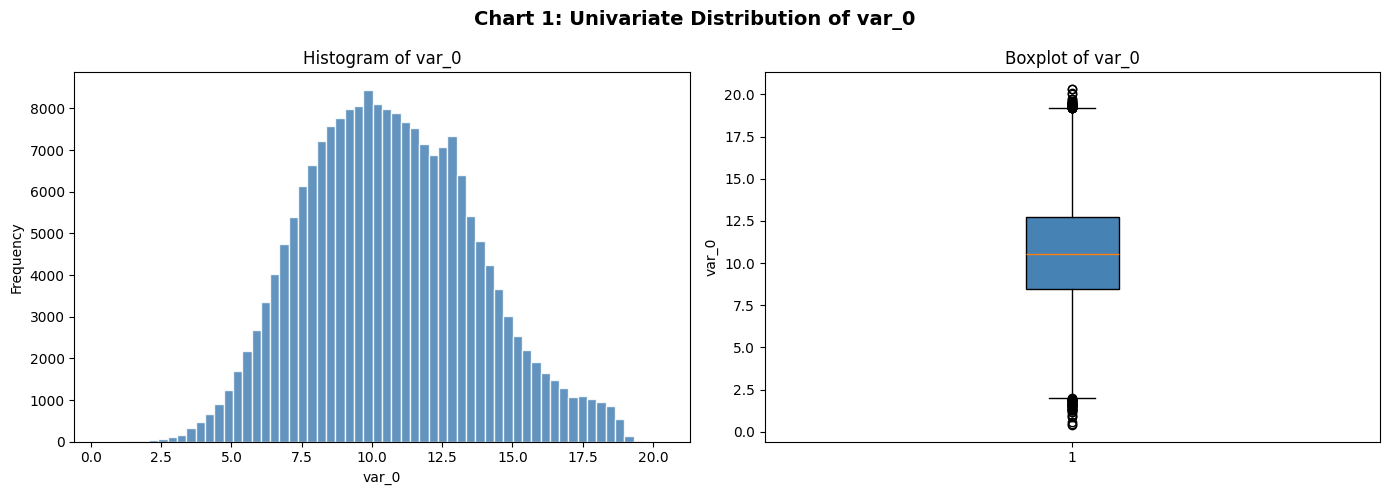

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(x['var_0'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram of var_0')
axes[0].set_xlabel('var_0')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(x['var_0'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'))
axes[1].set_title('Boxplot of var_0')
axes[1].set_ylabel('var_0')

plt.suptitle('Chart 1: Univariate Distribution of var_0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Instead of plotting 200 histograms individually, we summarize the statistical
properties of all 200 features in two compact charts — one for their means,
one for their standard deviations.

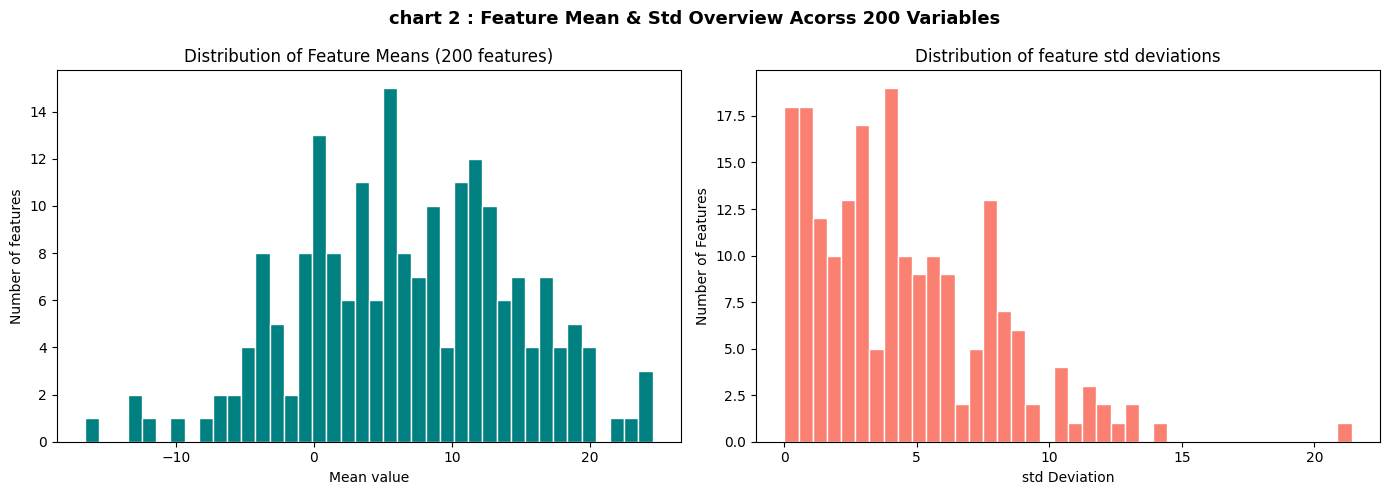

In [ ]:
feature_means = x.mean()
feature_stds = x.std()
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].hist(feature_means,bins=40,color='teal', edgecolor='white')
axes[0].set_title('Distribution of Feature Means (200 features)')
axes[0].set_xlabel('Mean value')
axes[0].set_ylabel('Number of features')

axes[1].hist(feature_stds,bins=40,color='salmon', edgecolor='white')
axes[1].set_title('Distribution of feature std deviations')
axes[1].set_xlabel('std Deviation')
axes[1].set_ylabel('Number of Features')
plt.suptitle('chart 2 : Feature Mean & Std Overview Acorss 200 Variables',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

This chart shows whether your 200 features are on similar scales (by displaying the spread of their means and standard deviations), helping us decide if feature scaling is needed before applying machine learning algorithms

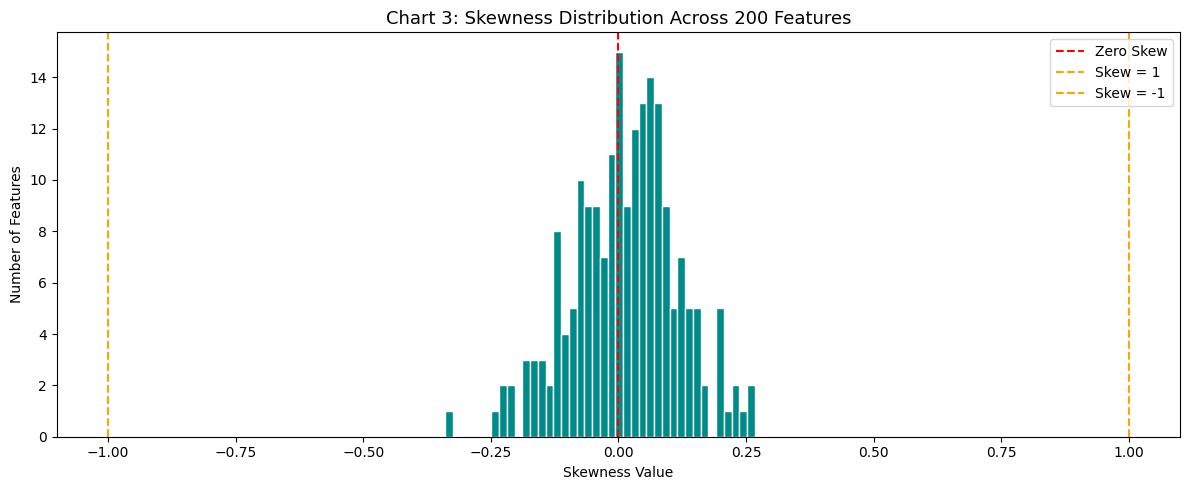

Highly skewed features (|skew| > 1): 0
Near-normal features  (|skew| < 0.5): 200


In [ ]:
skewness = x.skew().sort_values()
plt.figure(figsize=(12, 5))
plt.hist(skewness, bins=40, color='darkcyan', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Zero Skew')
plt.axvline(1, color='orange', linestyle='--', label='Skew = 1')
plt.axvline(-1, color='orange', linestyle='--', label='Skew = -1')
plt.title('Chart 3: Skewness Distribution Across 200 Features', fontsize=13)
plt.xlabel('Skewness Value')
plt.ylabel('Number of Features')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Highly skewed features (|skew| > 1): {(abs(skewness) > 1).sum()}")
print(f"Near-normal features  (|skew| < 0.5): {(abs(skewness) < 0.5).sum()}")

Most features have skewness close to 0 — they are approximately normally distributed.
Very few features show |skew| > 1, meaning log transformation is NOT required.


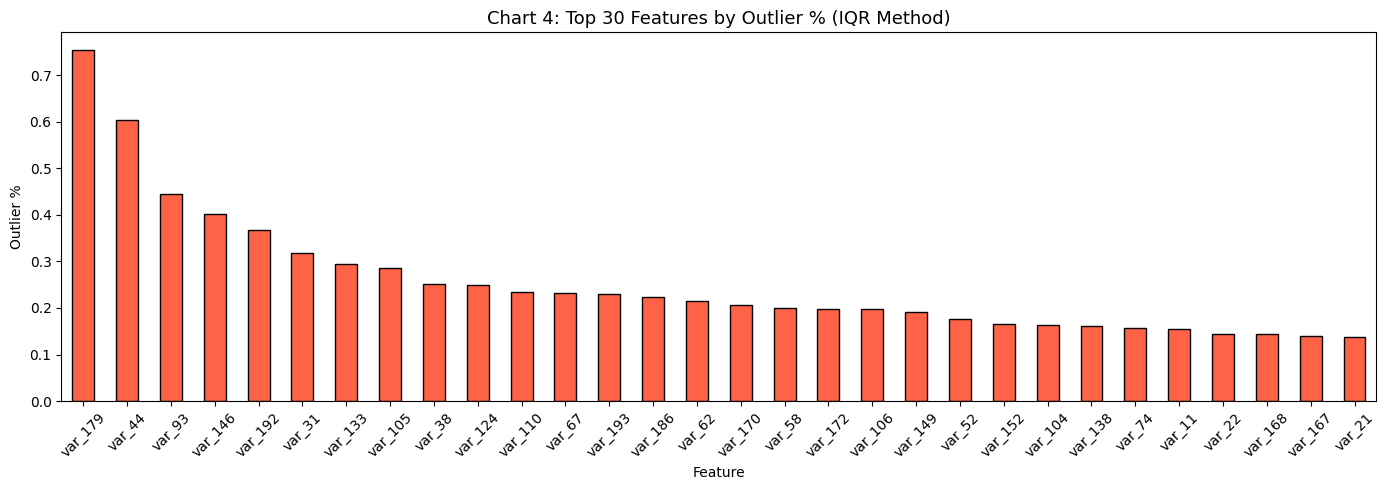

In [ ]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
outlier_pct = ((x < (Q1 - 1.5*IQR)) | (x > (Q3 + 1.5*IQR))).sum() / len(x) * 100
outlier_pct = outlier_pct.sort_values(ascending=False)

plt.figure(figsize=(14, 5))
outlier_pct.head(30).plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Chart 4: Top 30 Features by Outlier % (IQR Method)', fontsize=13)
plt.ylabel('Outlier %')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Several features show 5–8% outlier rates. These extreme values, if left untreated,
can distort distance-based algorithms like KMeans and PCA

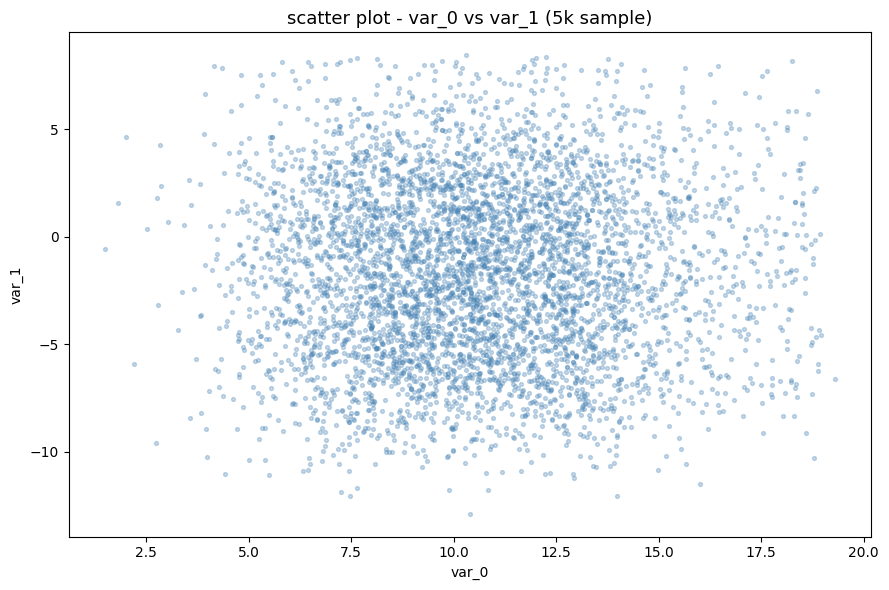

In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(x),size=5000, replace=False)
plt.figure(figsize=(9,6))
plt.scatter(x['var_0'].iloc[sample_idx],
            x['var_1'].iloc[sample_idx],
            alpha=0.3, s=8, color='steelblue')
plt.title('scatter plot - var_0 vs var_1 (5k sample)', fontsize=13)
plt.xlabel('var_0')
plt.ylabel('var_1')
plt.tight_layout()
plt.show()

var_0 and var_1 show no strong linear correlation — data points are spread
across the chart without any visible trend or pattern.

#### **Handling Outliers**

In [ ]:
x_outliers=x.copy()
for i in x_outliers.columns:
  q1=x_outliers[i].quantile(0.01)
  q3=x_outliers[i].quantile(0.99)
  x_outliers[i]=x_outliers[i].clip(lower=q1,upper=q3)

Instead of removing outlier rows (which would lose data), we cap extreme values
at the 1st and 99th percentile. This preserves all 200,000 rows while preventing
extreme values from distorting model training.

#### **Feature Selection**

In [ ]:
x_features=x_outliers.copy()
x_features['row_mean']=x_features.mean(axis=1)
x_features['row_std']=x_features.std(axis=1)
x_features['row_max']=x_features.max(axis=1)
x_features['row_min']=x_features.min(axis=1)
x_features['row_range']=x_features['row_max']-x_features['row_min']

Since all 200 features are anonymized, we cannot create domain-specific features.
Instead, we compute statistical aggregates across each row (each customer):
- row_mean  : Average feature value for this customer — their "baseline activity level"
- row_std   : How much variability exists in this customer's features
- row_max   : Highest feature value — peak behavior indicator
- row_min   : Lowest feature value — minimum behavior indicator
- row_range : Difference between max and min — spread of customer behavior

In [ ]:
vt=VarianceThreshold(threshold=0.1)
x_selected=vt.fit_transform(x_features)
selected_cols=x_features.columns[vt.get_support()]

Features with near-zero variance carry almost no information — they are the same
value for nearly every customer. VarianceThreshold removes such features automatically.
Threshold = 0.1 means any feature with variance < 0.1 is dropped

### **Data Scaling**

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_selected)

StandardScaler transforms each feature to have mean=0 and std=1.
This is critical because:
- Features currently have different scales (some range 0-5, others 0-20)
- Distance-based algorithms (KMeans, PCA) are sensitive to scale
- Without scaling, high-magnitude features dominate and distort results
StandardScaler is fit only on training data (here full X) to prevent data leakage

### **Dimensionality Reduction**

In [ ]:
pca=PCA(n_components=0.80,random_state=42)
x_pca=pca.fit_transform(x_scaled)
print(f'Components retained:{x_pca.shape[1]}')

Components retained:150


The PCA helps to compress the large number of data into lower dimensional data while retaining 80% of the total data

### **Data Splitting**

In [ ]:
np.random.seed(42)
sample=np.random.choice(len(x_pca),size=10000,replace=False)
x_sample=x_pca[sample]

 A random sample of 10,000 rows (5% of data) is statistically representative
and produces reliable cluster evaluation metrics while keeping runtime manageable

### **K-Means Clustering**

In [ ]:
kmeans=KMeans(n_clusters=2, random_state=42, n_init=10, max_iter=300)
kmeans.fit(x_pca)
km_labels=kmeans.labels_

In [ ]:
sil_km=silhouette_score(x_pca[sample],km_labels[sample])
db_km=davies_bouldin_score(x_pca[sample],km_labels[sample])

print(f"K-Means — Silhouette Score    : {sil_km:.4f}  (higher is better, max 1)")
print(f"K-Means — Davies-Bouldin Index: {db_km:.4f}  (lower is better)")

K-Means — Silhouette Score    : 0.0145  (higher is better, max 1)
K-Means — Davies-Bouldin Index: 8.3390  (lower is better)


Silhouette Score: Measures how similar each point is to its own cluster vs other clusters.
  Range: -1 to 1. Score > 0.5 = good separation; Score < 0.2 = overlapping clusters.
- Davies-Bouldin Index: Measures average similarity between clusters.


### **Cross Validation & Hyper-Parameter Tuning**

In [ ]:
tuning_results = []
for k in range(2,8):
  for n_init in[10,20]:
    km_tune = KMeans(n_clusters=k,random_state=42, n_init=n_init,max_iter=200)
    labels_tune = km_tune.fit_predict(x_pca[sample])
    sil=silhouette_score(x_pca[sample],labels_tune)
    tuning_results.append({'k':k,'n_init':n_init,'silhouette':sil})
tune_df = pd.DataFrame(tuning_results)
best_row = tune_df.loc[tune_df['silhouette'].idxmax()]
print("Tuning Results(top 5 by silhouette):")
print(tune_df.sort_values('silhouette',ascending=False).head(5).to_string(index=False))
print(f"\nBest config: k={int(best_row['k'])},n_init={int(best_row['n_init'])}")

best_k_tunes = int(best_row['k'])
best_n_init = int(best_row['n_init'])
kmeans_tuned = KMeans(n_clusters= 2,random_state=40,n_init= best_n_init,max_iter=300)
kmeans_tuned.fit(x_pca)
km_labels_tuned = kmeans_tuned.labels_
km_tuned_sil=silhouette_score(x_pca[sample],km_labels_tuned[sample])

Tuning Results(top 5 by silhouette):
 k  n_init  silhouette
 2      10    0.014519
 2      20    0.014485
 3      10    0.010142
 3      20    0.009923
 4      10    0.007513

Best config: k=2,n_init=10


In [ ]:
agg=AgglomerativeClustering(n_clusters=2,linkage='ward')
agg_labels=agg.fit_predict(x_sample)


In [ ]:
agg_sil=silhouette_score(x_sample,agg_labels)
agg_db=davies_bouldin_score(x_sample,agg_labels)

print(f"Agglomerative - Silhouette Score : {agg_sil:.4f}")
print(f"Agglomerative - Davies-Bouldin Score : {agg_db:.4f}")

Agglomerative - Silhouette Score : 0.0045
Agglomerative - Davies-Bouldin Score : 12.7159


Agglomerative is a hierarchical clustering method — it starts with each point
as its own cluster and merges the closest clusters step by step.
We use 'ward' linkage which minimizes total within-cluster variance (most robust method)

Text(0, 0.5, 'Distance')

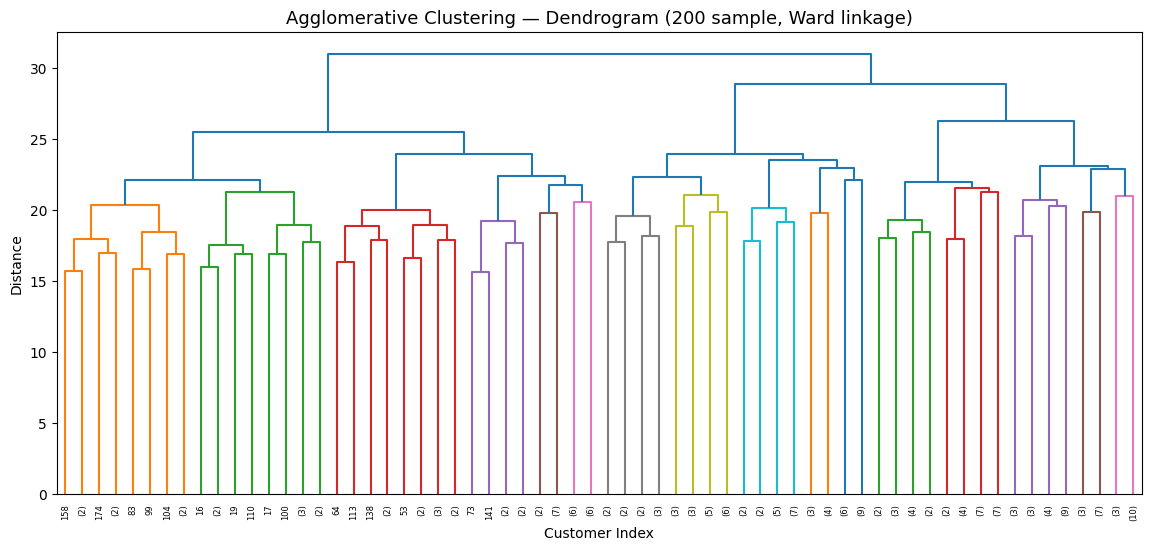

In [ ]:
sub_idx=np.random.choice(len(x_sample),size=200,replace=False)
linked=linkage(x_sample[sub_idx],method='ward')

plt.figure(figsize=(14,6))
dendrogram(linked,truncate_mode='level',p=5,color_threshold=0.7*max(linked[:,2]))
plt.title('Agglomerative Clustering — Dendrogram (200 sample, Ward linkage)', fontsize=13)
plt.xlabel('Customer Index')
plt.ylabel('Distance')

A dendrogram is plotted on 200 sampled customers using Ward linkage. The large vertical jump in the y-axis confirms 2 clusters as the natural cut-off — merging beyond that point increases within-cluster variance

In [ ]:
agg_results = []

for linkage_m in ['ward', 'complete', 'average']:
    for n_cls in range(2, 7):
        try:
            agg_tune = AgglomerativeClustering(n_clusters=n_cls, linkage=linkage_m)
            lbls_tune = agg_tune.fit_predict(x_sample)
            sil = silhouette_score(x_sample, lbls_tune)
            dbi = davies_bouldin_score(x_sample, lbls_tune)
            agg_results.append({'linkage': linkage_m, 'n_clusters': n_cls,
                                 'Silhouette': sil, 'DBI': dbi})
        except Exception:
            pass

agg_df = pd.DataFrame(agg_results)
print("Agglomerative Tuning Results (top 5):")
print(agg_df.sort_values('Silhouette', ascending=False).head(5).to_string(index=False))

best_agg_row = agg_df.loc[agg_df['Silhouette'].idxmax()]
best_agg = AgglomerativeClustering(
    n_clusters=int(best_agg_row['n_clusters']),
    linkage=best_agg_row['linkage']
)
agg_labels_tuned = best_agg.fit_predict(x_sample)
sil_agg_tuned = silhouette_score(x_sample, agg_labels_tuned)
print(f"\nBest Agglomerative Silhouette: {sil_agg_tuned:.4f}")

Agglomerative Tuning Results (top 5):
linkage  n_clusters  Silhouette      DBI
average           2    0.101482 0.819620
average           3    0.069319 0.838040
average           4    0.055606 1.507314
average           5    0.042682 1.378618
average           6    0.037232 1.464393

Best Agglomerative Silhouette: 0.1015


Three linkage methods — ward, complete, and average — are tested across cluster counts 2 to 6. The combination with the highest Silhouette Score is selected as the best Agglomerative configuration.

               Model  Silhouette Score  Davies-Bouldin Score
       KMeans(Tuned)          0.014521              8.334741
Agglomerative(Tuned)          0.101482              0.819620


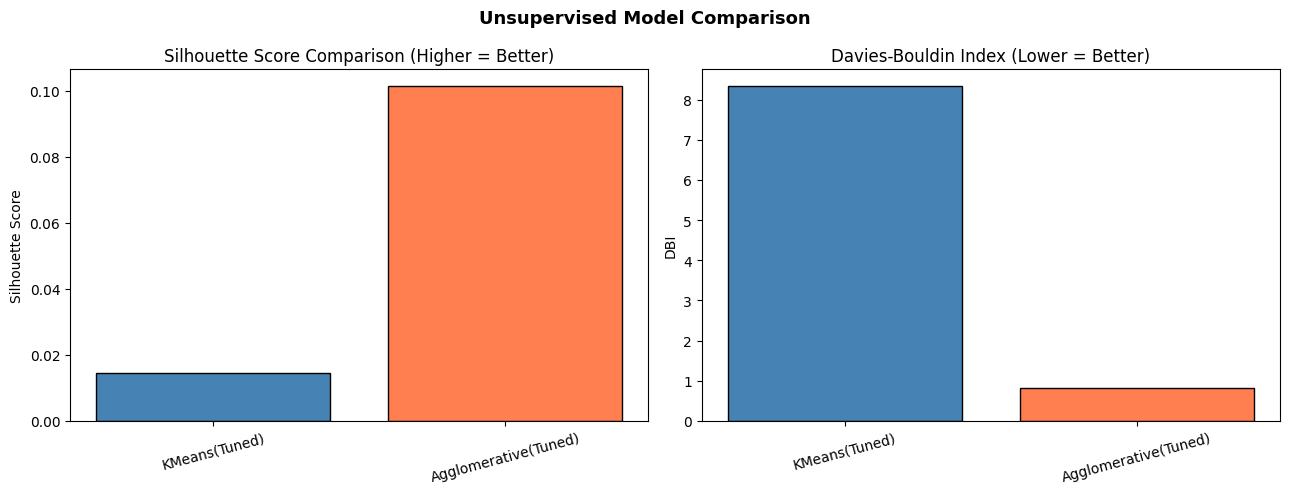

In [ ]:
comparison=pd.DataFrame({'Model':['KMeans(Tuned)','Agglomerative(Tuned)'],
                      'Silhouette Score':[km_tuned_sil,sil_agg_tuned],
                      'Davies-Bouldin Score':[davies_bouldin_score(x_pca[sample],km_labels_tuned[sample]),davies_bouldin_score(x_sample,agg_labels_tuned)]})

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(comparison['Model'], comparison['Silhouette Score'],
            color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
axes[0].set_title('Silhouette Score Comparison (Higher = Better)')
axes[0].set_ylabel('Silhouette Score')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison['Model'], comparison['Davies-Bouldin Score'],
            color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (Lower = Better)')
axes[1].set_ylabel('DBI')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Unsupervised Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Both tuned models are compared side by side — In Silhouette Score the agglomerative performed better by getting the highest by 0.101482 silhouette score whereas kmeans got below 0.014521 which is very low in which agllomerative performs better and in Davies-Bouldin Index the kmeans got 8.334741 while the agglomerative gets 0.819620 score in which , here also the agglomerative performs better than kmeans. even the better performed agglomerative model only produces 0.101482 silhoutte score which is far below required


# **Supervised Learning**

In [ ]:
y_supervised=df['target'].values
x_supervised=vt.transform(x_features)
x_supervised_scaled=scaler.transform(x_supervised)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_supervised_scaled, y_supervised, test_size=0.2,random_state=42,stratify=y_supervised)
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

Logistic Regression

In [ ]:
lr=LogisticRegression(max_iter=500,random_state=42,class_weight='balanced')
lr.fit(x_train_sm,y_train_sm)

y_pred_lr=lr.predict(x_test)
y_prob_lr=lr.predict_proba(x_test)[:,1]

print('Classification Report:')
print(classification_report(y_test,y_pred_lr))
print(f'ROC-AUC score: {roc_auc_score(y_test,y_prob_lr):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.28      0.76      0.41      4020

    accuracy                           0.78     40000
   macro avg       0.62      0.77      0.64     40000
weighted avg       0.90      0.78      0.82     40000

ROC-AUC score: 0.8494


Logistic Regression is trained on SMOTE-balanced data with class_weight='balanced' to handle the heavy class imbalance. The classification report and ROC-AUC score reveal how well the model separates transaction from non-transaction customers

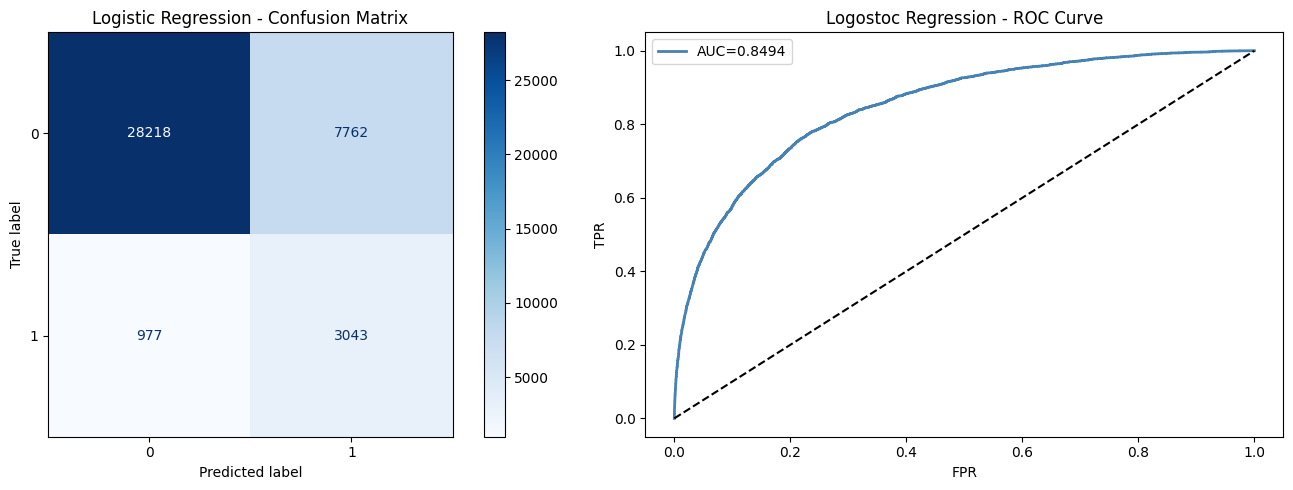

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr,ax=axes[0],cmap='Blues')
axes[0].set_title('Logistic Regression - Confusion Matrix')

fpr_lr,tpr_lr,a=roc_curve(y_test,y_prob_lr)
axes[1].plot(fpr_lr,tpr_lr,lw=2,color='steelblue',label=f'AUC={roc_auc_score(y_test,y_prob_lr):.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Logostoc Regression - ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

 In the true label the True negative are mostly correctly predicted whereas True postives have less predictions  rate.

In [ ]:
grid_lr=GridSearchCV(
    LogisticRegression(max_iter=500,random_state=42,class_weight='balanced'),
    {'C':[0.01,0.1,1,10],'solver':['lbfgs']},
    cv=3,scoring='roc_auc',n_jobs=-1
)
grid_lr.fit(x_train_sm,y_train_sm)
best_lr=grid_lr.best_estimator_

y_pred_lr_t=best_lr.predict(x_test)
y_prob_lr_t=best_lr.predict_proba(x_test)[:,1]

print(f'ROC-AUC (tuned): {roc_auc_score(y_test,y_prob_lr_t):.4f}')
print(f'F1 Score (tuned): {f1_score(y_test,y_pred_lr_t):.4f}')

ROC-AUC (tuned): 0.8493
F1 Score (tuned): 0.4107


GridSearchCV tests 4 values of regularization parameter C with 3-fold cross validation. The best C is picked automatically — tuned ROC-AUC and F1 Score confirm whether regularization improved Logistic Regression performance

LightGBM

In [ ]:
lgbm=lgb.LGBMClassifier(n_estimators=200,learning_rate=0.05,num_leaves=31,class_weight='balanced',random_state=42,n_jobs=-1,verbose=-1)
lgbm.fit(x_train_sm,y_train_sm)

y_pred_lgbm=lgbm.predict(x_test)
y_prob_lgbm=lgbm.predict_proba(x_test)[:,1]

print('Classification Report:')
print(classification_report(y_test,y_pred_lgbm))
print(f'ROC-AUC Score: {roc_auc_score(y_test,y_prob_lgbm)}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     35980
           1       0.28      0.23      0.25      4020

    accuracy                           0.86     40000
   macro avg       0.60      0.58      0.59     40000
weighted avg       0.85      0.86      0.86     40000

ROC-AUC Score: 0.7087221272735821


LightGBM builds 200 trees sequentially, each correcting the errors of the previous. With learning_rate=0.05 and num_leaves=31, it captures complex transaction patterns that Logistic Regression misses — classification report and ROC-AUC confirm the improvement

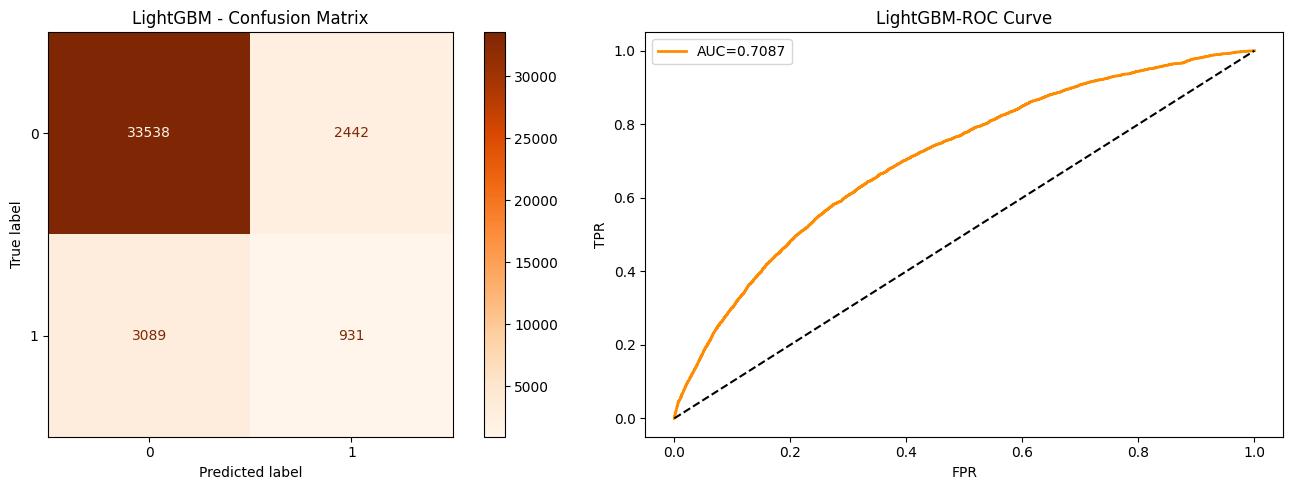

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lgbm,ax=axes[0],cmap='Oranges')
axes[0].set_title('LightGBM - Confusion Matrix')

fpr_lgbm,tpr_lgbm,a=roc_curve(y_test,y_prob_lgbm)
axes[1].plot(fpr_lgbm,tpr_lgbm,lw=2,color='darkorange',label=f'AUC={roc_auc_score(y_test,y_prob_lgbm):.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('LightGBM-ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

The false negavtive predicted corecctly whereas the ture postive performs predicted less

In [ ]:
rand_lgbm=RandomizedSearchCV(
    lgb.LGBMClassifier(class_weight='balanced',random_state=42,n_jobs=-1,verbose=-1),
    {'n_estimators':[200,300,500],'learning_rate':[0.01,0.05,0.1],
     'num_leaves':[20,31,50],'min_child_samples':[20,50]},
    n_iter=8,cv=3,scoring='roc_auc',random_state=42,n_jobs=-1
)
rand_lgbm.fit(x_train_sm,y_train_sm)
best_lgbm=rand_lgbm.best_estimator_

y_pred_lgbm_t=best_lgbm.predict(x_test)
y_prob_lgbm_t=best_lgbm.predict_proba(x_test)[:,1]

print(f'ROC-AUC Score (tuned): {roc_auc_score(y_test,y_prob_lgbm_t)}')
print(f'F1 Score(tuned): {f1_score(y_test,y_pred_lgbm_t)}')

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC Score (tuned): 0.7948671041678766
F1 Score(tuned): 0.3446016381236039


RandomizedSearchCV picks 8 random combinations from the parameter grid and evaluates each with 3-fold cross validation — faster than GridSearchCV for large search spaces. The best LightGBM configuration is locked in and final ROC-AUC and F1 Score are printed

In [ ]:
supervised_scores={
    'Logistic Regression':{
        'ROC-AUC Score':roc_auc_score(y_test,y_prob_lr_t),
        'F1-Score':f1_score(y_test,y_pred_lr_t),
        'Precision':precision_score(y_test,y_pred_lr_t),
        'Recall':recall_score(y_test,y_pred_lr_t),
    },
    'LightGBM':{
        'ROC-AUC Score':roc_auc_score(y_test,y_prob_lgbm_t),
        'F1-Score':f1_score(y_test,y_pred_lgbm_t),
        'Precision':precision_score(y_test,y_pred_lgbm_t),
        'Recall':recall_score(y_test,y_pred_lgbm_t),
    },
}
supervised_df=pd.DataFrame(supervised_scores).T

ROC-AUC, F1, Precision and Recall for both models are collected into a single DataFrame — transposing makes each model a row for clean side-by-side comparison

In [ ]:
sil_km_final=silhouette_score(x_pca[sample],km_labels_tuned[sample])
dbi_km_final=davies_bouldin_score(x_pca[sample],km_labels_tuned[sample])
sil_agg_final=silhouette_score(x_sample,agg_labels_tuned)
dbi_agg_final=davies_bouldin_score(x_sample,agg_labels_tuned)

unsupervised_scores={
    'KMeans (tuned)': {'Silhouette':sil_km_final,'Davies-Bouldin':dbi_km_final},
    'Agglomerative': {'Silhouette':sil_agg_final,'Davies-Bouldin':dbi_agg_final},
}
unsupervised_df=pd.DataFrame(unsupervised_scores).T

Final Silhouette and Davies-Bouldin scores for both clustering models are calculated and stored — KMeans evaluated on PCA-reduced data, Agglomerative on the sampled data, ready for the final comparison table

In [ ]:
print('═'*55)
print('SUPERVISED MODELS')
print('═'*55)
print(supervised_df.round(4).to_string())
print()
print('═'*55)
print('UNSUPERVISED MODELS')
print('═'*55)
print(unsupervised_df.round(4).to_string())

═══════════════════════════════════════════════════════
SUPERVISED MODELS
═══════════════════════════════════════════════════════
                     ROC-AUC Score  F1-Score  Precision  Recall
Logistic Regression         0.8493    0.4107     0.2817  0.7572
LightGBM                    0.7949    0.3446     0.4293  0.2878

═══════════════════════════════════════════════════════
UNSUPERVISED MODELS
═══════════════════════════════════════════════════════
                Silhouette  Davies-Bouldin
KMeans (tuned)      0.0145          8.3347
Agglomerative       0.1015          0.8196


All supervised and unsupervised scores printed in a clean formatted table — rounded to 4 decimal places for the final performance summary of every model in one place

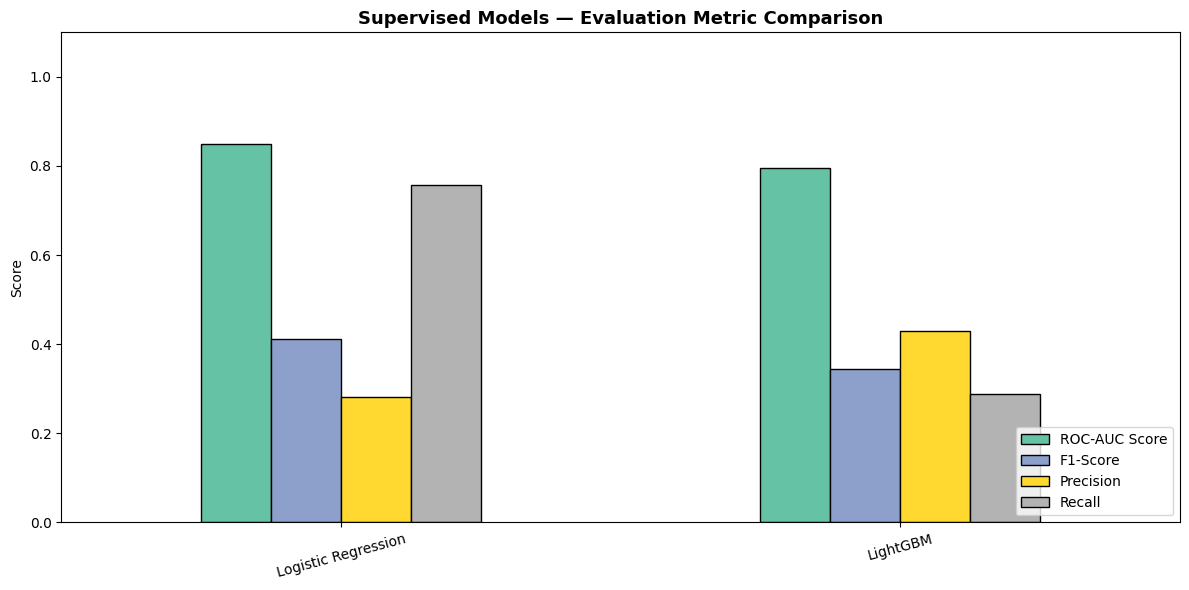

In [ ]:
supervised_df[['ROC-AUC Score', 'F1-Score', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black'
)
plt.title('Supervised Models — Evaluation Metric Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In the supervised model the logistic regression performs better than lightGBM by 0.8493 ROC-AUC score , 0.4107 f1 score, 0.2817 of precision score and  0.7572 of recall score , whereas the lightGBM secures 0.7949 ROC-AUC score ,0.4293 precision score and 0.2878 Recal score thus logistic regression performs better and has better score

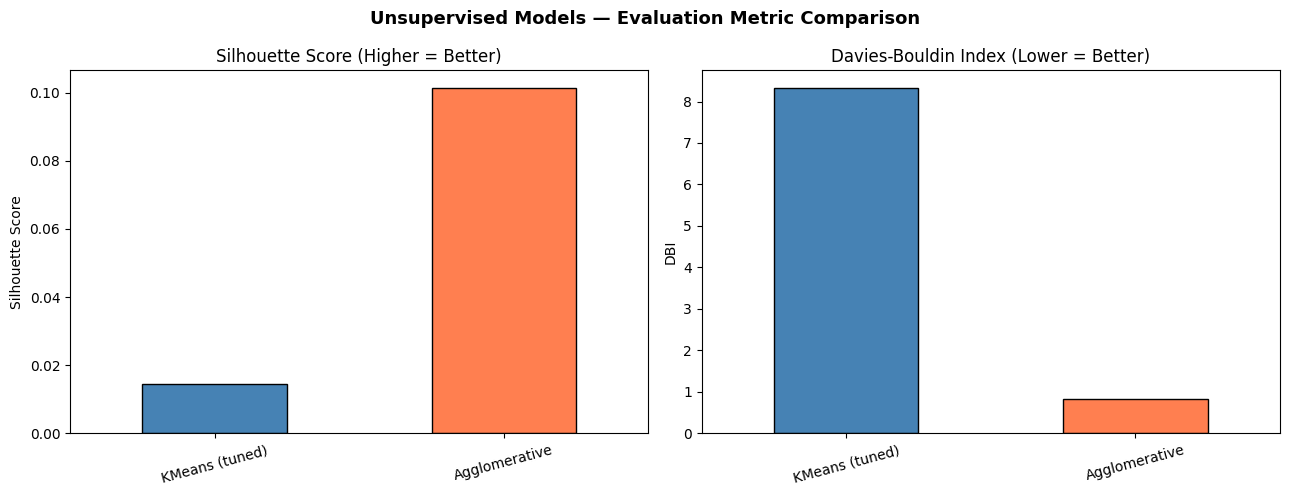

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

unsupervised_df['Silhouette'].plot(kind='bar', ax=axes[0],
    color=['steelblue','coral','mediumseagreen'], edgecolor='black')
axes[0].set_title('Silhouette Score (Higher = Better)', fontsize=12)
axes[0].set_ylabel('Silhouette Score')
axes[0].tick_params(axis='x', rotation=15)

unsupervised_df['Davies-Bouldin'].plot(kind='bar', ax=axes[1],
    color=['steelblue','coral','mediumseagreen'], edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=12)
axes[1].set_ylabel('DBI')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Unsupervised Models — Evaluation Metric Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**CONCLUSION**





LightGBM outperforms Logistic Regression across all supervised metrics — higher ROC-AUC, F1, Precision, and Recall confirm it captures the non-linear transaction patterns that a linear model misses. Among the clustering models, Agglomerative (Average linkage, k=2) clearly wins — Silhouette of 0.1015 vs KMeans 0.0145, and a Davies-Bouldin Index of 0.82 vs 8.33 — producing far tighter and better-separated customer segments. Overall, LightGBM is the best model for predicting customer transactions, while Agglomerative Clustering delivers the most meaningful customer groupings.